# δALK vertical profiles

In [1]:
import sys

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pop_tools

sys.path.insert(0, '/global/cfs/cdirs/m4746/Users/nora/Ocean-CDR-Atlas-v0/workflows')
from analysis import (
    open_true_experiment,
    open_deficit_tracer_experiment,
    INVERSE_POLYGON_MAP,
)

/global/common/software/m4632/conda/cworthy/lib/python3.11/site-packages/pop_tools/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
# POP gx1v7 grid — history files have NaN TLONG/TLAT/_FillValue, so use pop_tools
print("Loading POP gx1v7 grid …")
PG    = pop_tools.get_grid("POP_gx1v7")
TAREA = PG.TAREA.values   # (nlat, nlon), cm²
print("Done.")

Loading POP gx1v7 grid …
Done.


In [3]:
def parse_experiment(experiment_str):
    """'DOR 437' → ('dor', 437)."""
    parts = experiment_str.strip().split()
    return parts[0].lower(), int(parts[1])


def date_to_time_index(date_str, intervention_year=1999, intervention_month=1):
    """'YYYY-MM' → 0-based integer index into the monthly time series."""
    y, m = int(date_str[:4]), int(date_str[5:7])
    return (y - intervention_year) * 12 + (m - intervention_month)

In [4]:
def compare_dalk_2x3(
    experiment,
    dates,
    max_depth=1000,
    intervention_year=1999,
    intervention_month="01",
    realization="001",
    colors=None,
    figsize=None,
    save=False,
):
    """2×3 panel figure: 5 per-date δALK profiles + 1 difference panel.

    Panels (a)–(e): truth (date color) + CDR tracer (black dashed) for each date.
    Panel (f): CDR tracer − truth difference for all 5 dates in their date colors.

    Parameters
    ----------
    experiment : str
        e.g. 'OAE 437'.
    dates : list of str
        Exactly 5 calendar dates as 'YYYY-MM'.
    colors : list or None
        5 colors, one per date.  None → tab10.
    """
    mode, pid = parse_experiment(experiment)
    pid_str   = f"{pid:03d}"
    b, p      = INVERSE_POLYGON_MAP[pid]

    exp_id = rf"{pid}\!\ominus" if mode == "dor" else rf"{pid}\!\oplus"
    exp_label = rf"$P{exp_id}$"
    
    if len(dates) != 5:
        raise ValueError(f"Expected exactly 5 dates, got {len(dates)}")

    suffix    = f"all-{mode}-daily"
    antitracer_alk_varname = f"DELTAALK{pid_str}"
    tarea_m2  = xr.DataArray(TAREA * 1e-4, dims=["nlat", "nlon"])

    if colors is None:
        _cm = plt.get_cmap("tab10")
        colors = [_cm(i) for i in range(5)]

    _figsize = figsize if figsize is not None else (3.5 * 3, 7 * 2)
    fig, axes = plt.subplots(2, 3, figsize=_figsize, sharey=True)
    panel_labels = "abcdef"

    profiles = []

    for i, (date, color) in enumerate(zip(dates, colors)):
        row, col = divmod(i, 3)
        ax = axes[row][col]
        t_idx = date_to_time_index(date, intervention_year, int(intervention_month))

        # Truth
        ds_true = open_true_experiment(
            pid_str, mode=mode,
            intervention_month=intervention_month,
            intervention_year=str(intervention_year),
            realization=realization,
            file_index=t_idx,
        )
        da_true      = (ds_true["ALK"] - ds_true["ALK_ALT_CO2"]).squeeze(drop=True)
        z_m          = ds_true.z_t.values / 100.0
        profile_true = (da_true * tarea_m2).sum(["nlat", "nlon"]).values

        # CDR tracer
        profile_anti = None
        try:
            ds_anti = open_deficit_tracer_experiment(
                suffix,
                intervention_month=intervention_month,
                intervention_year=str(intervention_year),
                realization=realization,
                file_index=t_idx,
            )
            if antitracer_alk_varname in ds_anti.data_vars:
                da_anti      = ds_anti[antitracer_alk_varname].squeeze(drop=True)
                profile_anti = (da_anti * tarea_m2).sum(["nlat", "nlon"]).values
        except (FileNotFoundError, OSError):
            pass

        profiles.append((z_m, profile_true, profile_anti))
        depth_mask = z_m <= max_depth

        ax.plot(profile_true[depth_mask], z_m[depth_mask],
                color=color, lw=2, label="Truth")
        if profile_anti is not None:
            ax.plot(profile_anti[depth_mask], z_m[depth_mask],
                    color="k", lw=2, ls="--", label="CDR tracer")

        ax.axvline(0, color="gray", lw=0.8, ls="--")
        ax.set_ylim(max_depth, 0)
        ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
        ax.set_title(f"({panel_labels[i]}) {exp_label}: {date}")
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
        ax.set_xlabel(r"mmol m$^{-1}$")
        if col == 0:
            ax.set_ylabel("Depth (m)")
        ax.legend()

    # Panel (f): differences in date colors
    ax_f = axes[1][2]
    for date, color, (z_m, profile_true, profile_anti) in zip(dates, colors, profiles):
        if profile_anti is None:
            continue
        depth_mask   = z_m <= max_depth
        profile_diff = profile_anti - profile_true
        ax_f.plot(profile_diff[depth_mask], z_m[depth_mask],
                  color=color, lw=2, label=date)

    ax_f.axvline(0, color="gray", lw=0.8, ls="--")
    ax_f.set_ylim(max_depth, 0)
    ax_f.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
    ax_f.set_xlabel(r"mmol m$^{-1}$")
    ax_f.legend(title="date")
    ax_f.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    ax_f.set_title(f"(f) {exp_label} CDR tracer - truth")

    fig.tight_layout()

    if save:
        date_tag = "_".join(d.replace("-", "") for d in dates)
        fname = f"figures/dalk_profiles_2x3_{experiment.replace(' ', '_')}_{date_tag}.png"
        fig.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"Saved: {fname}")

    return fig, axes

Saved: figures/dalk_profiles_2x3_OAE_437_199902_200001_200401_200901_201312.png


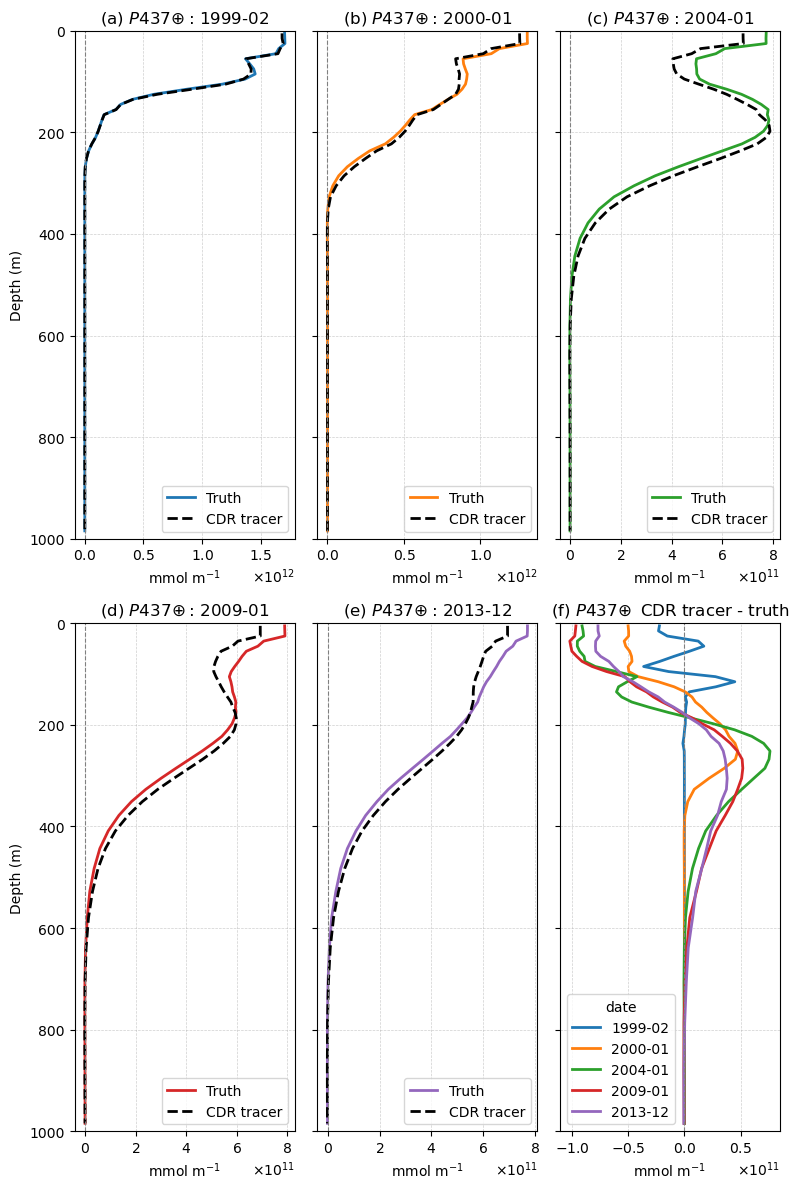

In [21]:
fig, axes = compare_dalk_2x3(
    "OAE 437",
    dates=["1999-02", "2000-01", "2004-01", "2009-01", "2013-12"],
    figsize=(8, 12),
    save=True,
)

Saved: figures/dalk_profiles_2x3_OAE_140_199902_200001_200401_200901_201312.png


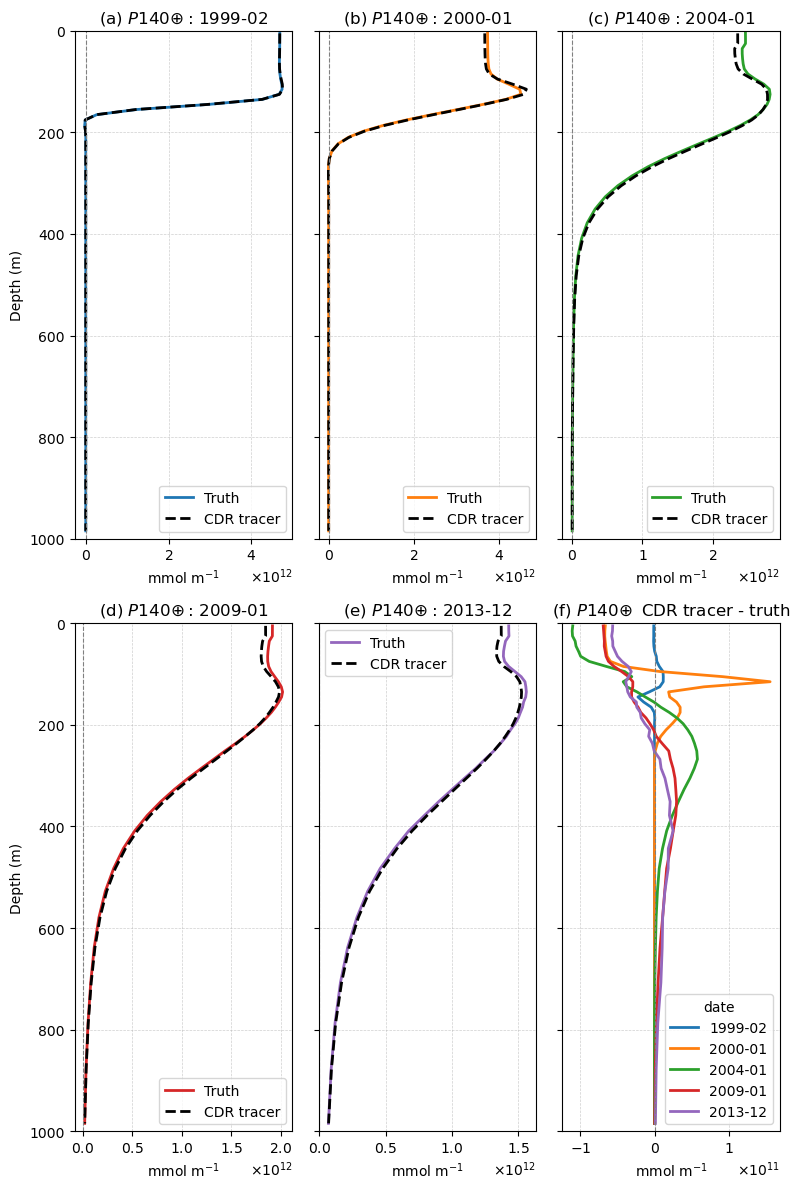

In [22]:
fig, axes = compare_dalk_2x3(
    "OAE 140",
    dates=["1999-02", "2000-01", "2004-01", "2009-01", "2013-12"],
    figsize=(8, 12),
    save=True,
)

Saved: figures/dalk_profiles_2x3_OAE_674_199902_200001_200401_200901_201312.png


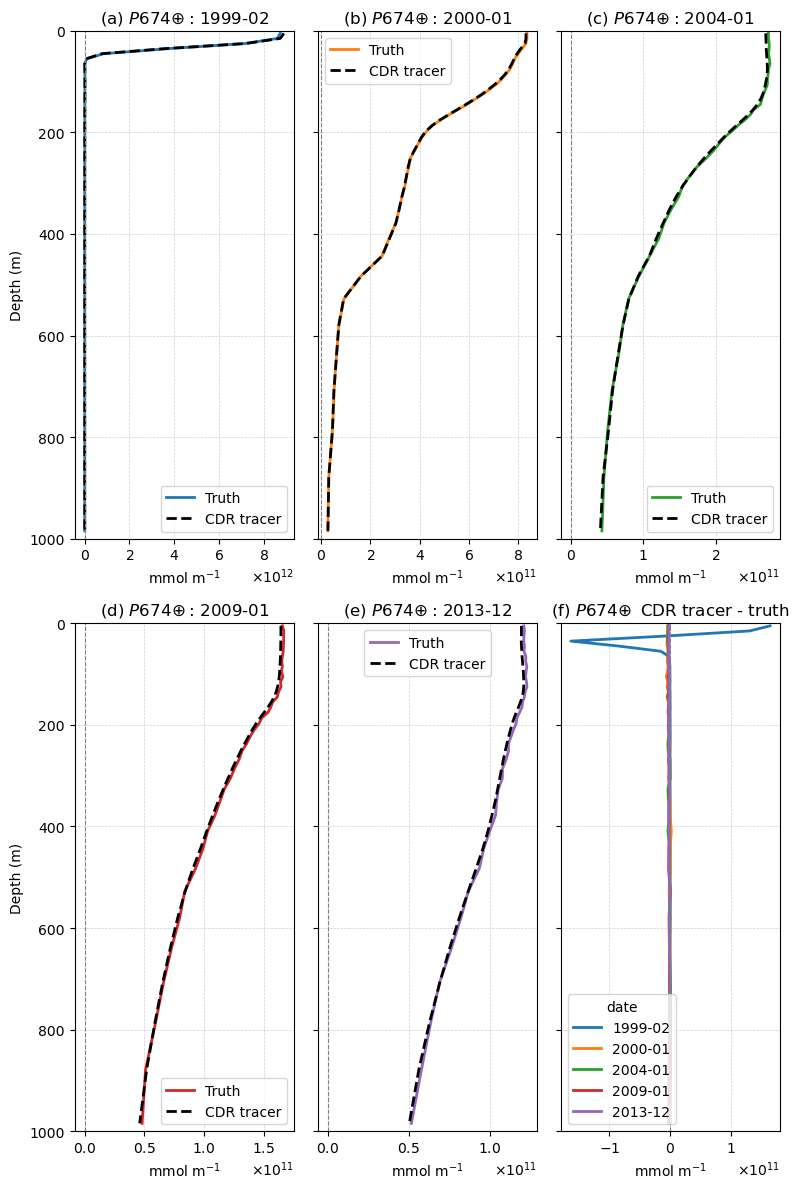

In [23]:
fig, axes = compare_dalk_2x3(
    "OAE 674",
    dates=["1999-02", "2000-01", "2004-01", "2009-01", "2013-12"],
    figsize=(8, 12),
    save=True,
)

Saved: figures/dalk_profiles_2x3_OAE_164_199902_200001_200401_200901_201312.png


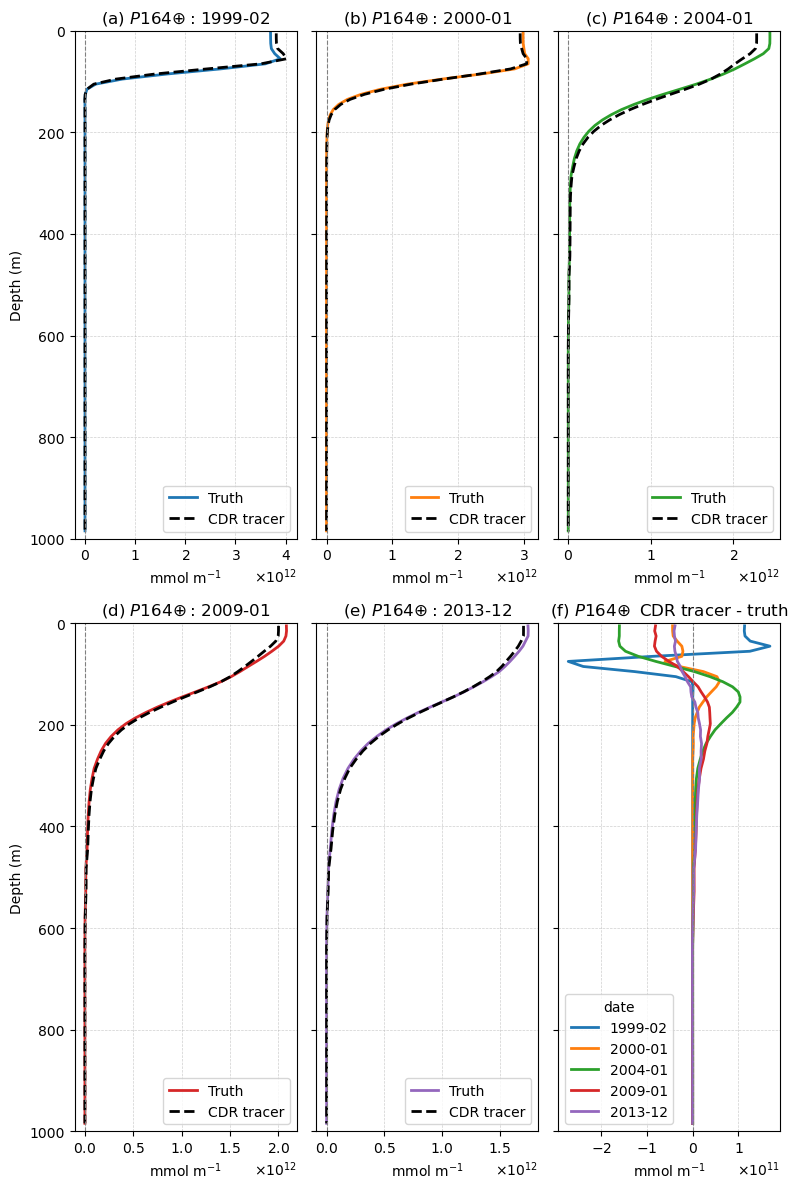

In [28]:
fig, axes = compare_dalk_2x3(
    "OAE 164",
    dates=["1999-02", "2000-01", "2004-01", "2009-01", "2013-12"],
    figsize=(8, 12),
    save=True,
)

Saved: figures/dalk_profiles_2x3_OAE_027_199902_200001_200401_200901_201312.png


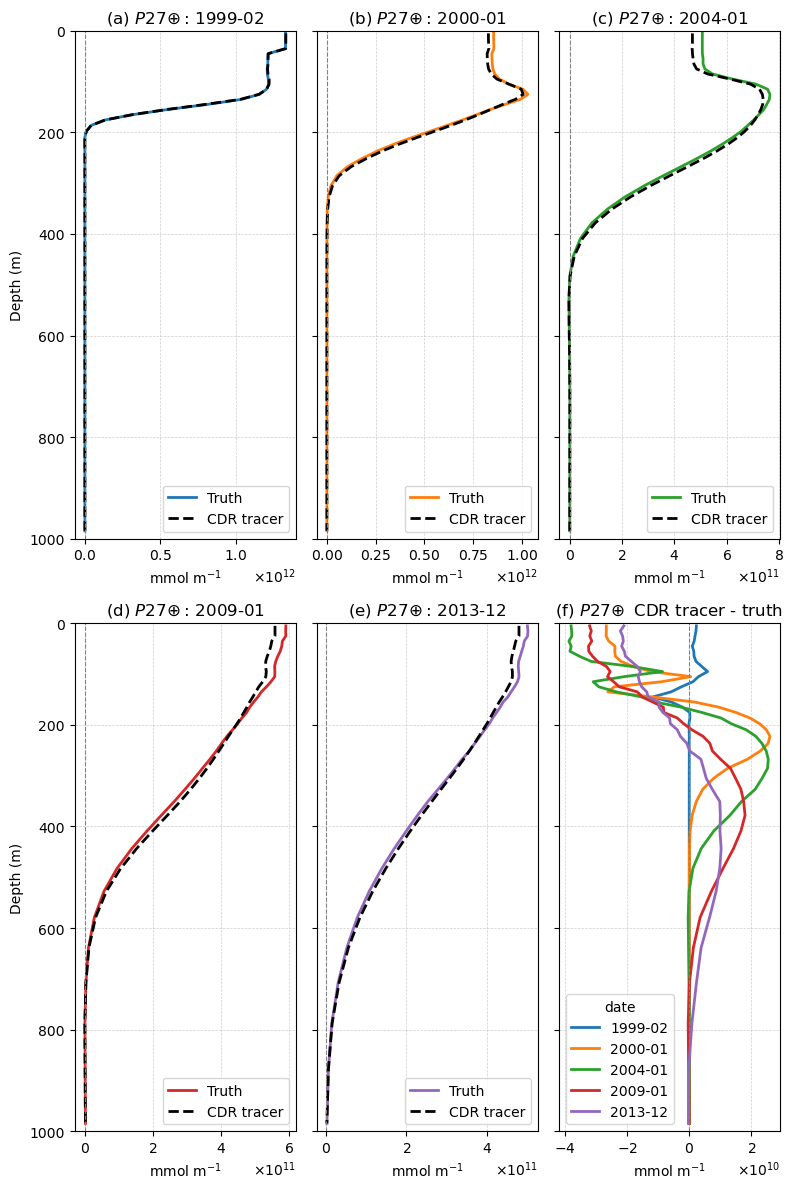

In [29]:
fig, axes = compare_dalk_2x3(
    "OAE 027",
    dates=["1999-02", "2000-01", "2004-01", "2009-01", "2013-12"],
    figsize=(8, 12),
    save=True,
)

Saved: figures/dalk_profiles_2x3_OAE_011_199902_200001_200401_200901_201312.png


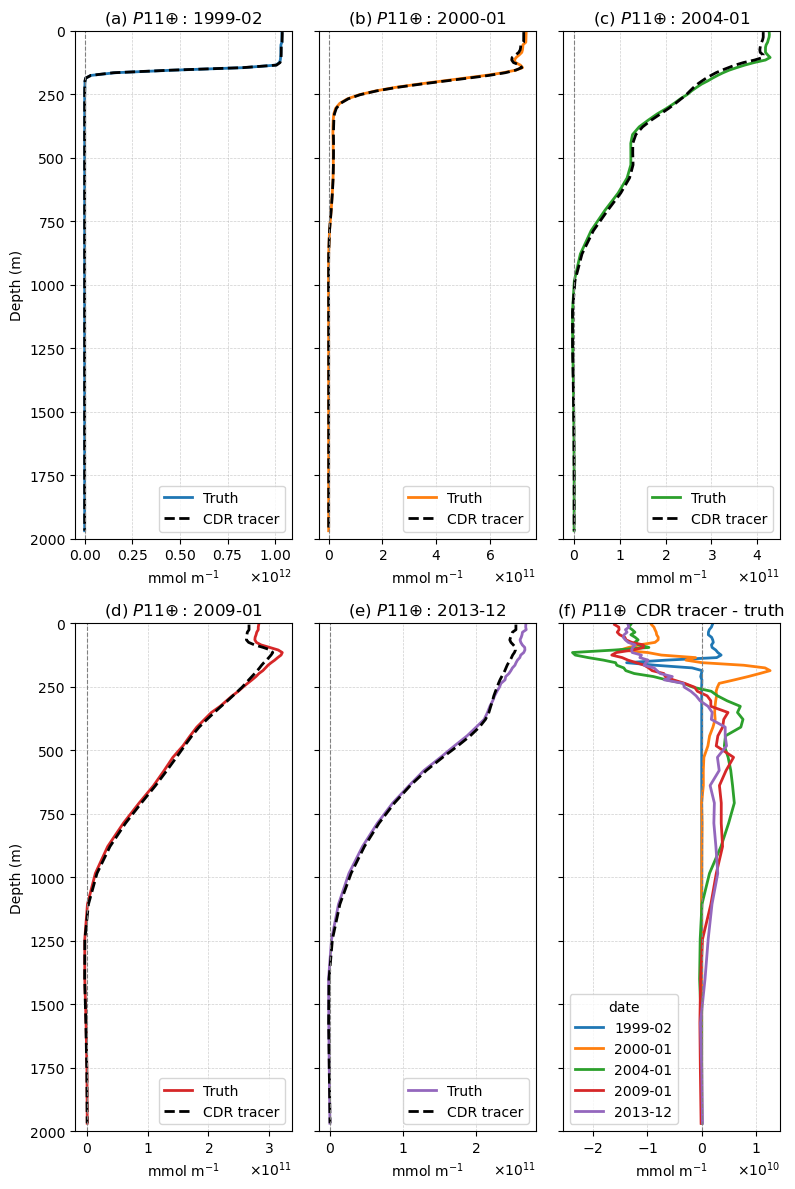

In [5]:
fig, axes = compare_dalk_2x3(
    "OAE 011",
    dates=["1999-02", "2000-01", "2004-01", "2009-01", "2013-12"],
    figsize=(8, 12),
    save=True,
    max_depth=2000
)

Saved: figures/dalk_profiles_2x3_OAE_401_199902_200001_200401_200901_201312.png


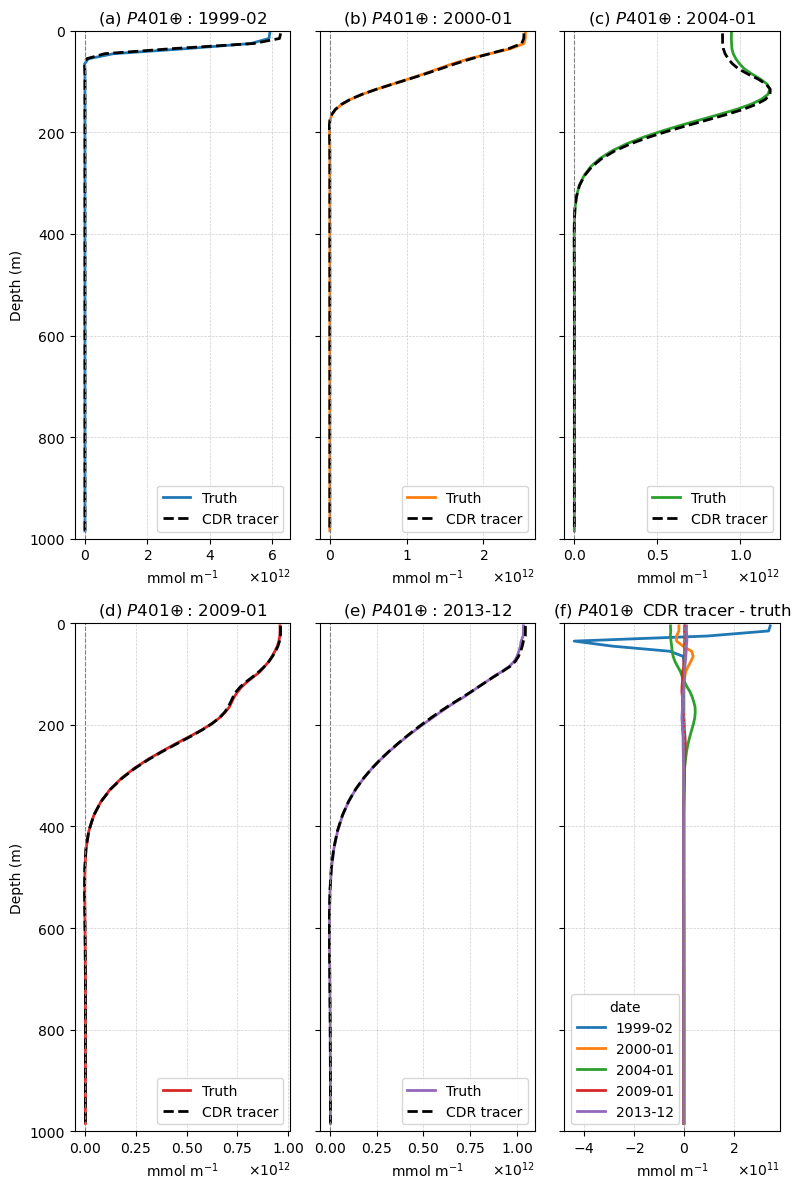

In [31]:
fig, axes = compare_dalk_2x3(
    "OAE 401",
    dates=["1999-02", "2000-01", "2004-01", "2009-01", "2013-12"],
    figsize=(8, 12),
    save=True,
)

Saved: figures/dalk_profiles_2x3_OAE_005_199902_200001_200401_200901_201312.png


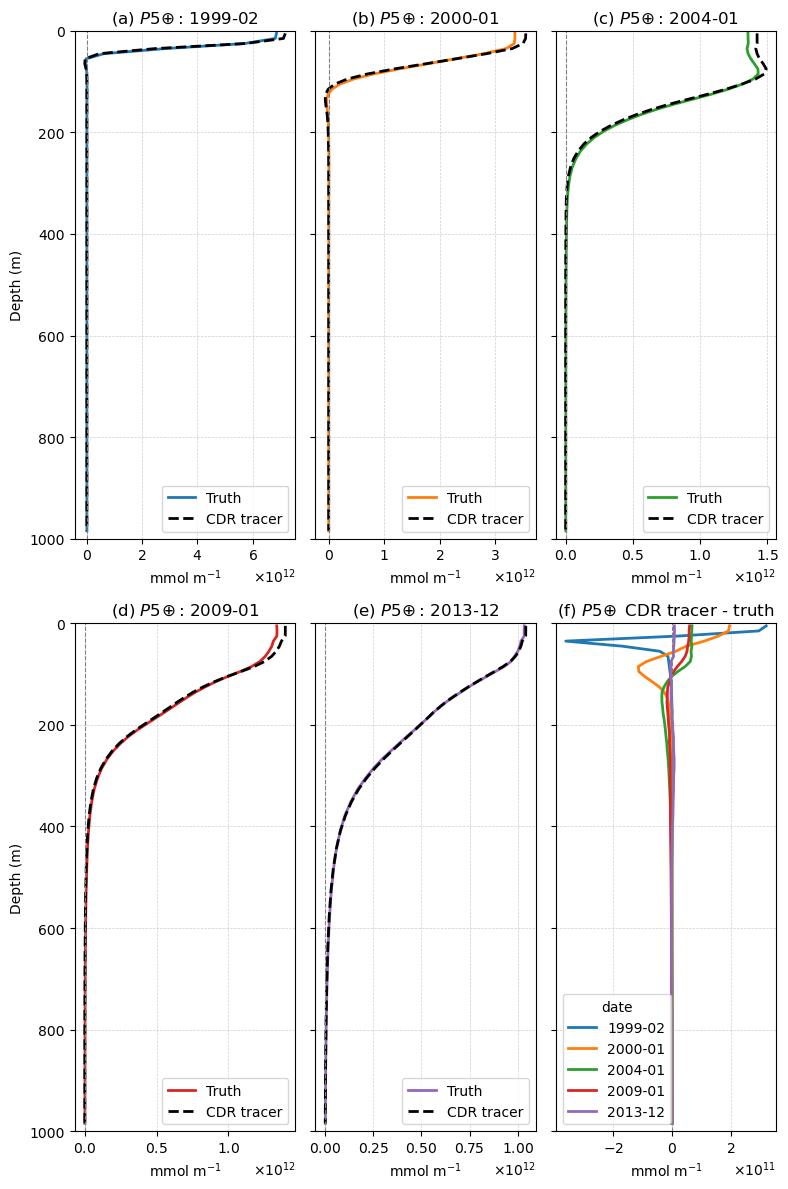

In [32]:
fig, axes = compare_dalk_2x3(
    "OAE 005",
    dates=["1999-02", "2000-01", "2004-01", "2009-01", "2013-12"],
    figsize=(8, 12),
    save=True,
)